<a href="https://colab.research.google.com/github/gnoejh/AIBookGitHub/blob/main/3_activation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Activation Functions

## Components of Neural Networks

## Activation Functions in Neural Networks

This presentation covers various activation functions used in neural networks, their mathematical formulations, diagrammatic representations using Mermaid, and PyTorch implementations.

## Introduction to Activation Functions

Activation functions are crucial components that introduce non-linearities into neural networks, enabling them to learn complex patterns and relationships in data. They are applied after the linear transformation in each neuron.

### Connection to Artificial Neurons

In the context of an artificial neuron (covered in the [Artificial Neuron notebook](./artificial%20neuron.ipynb)), activation functions are the final step in the computation:

$$ y = f(\mathbf{w}^T \mathbf{x} + b) $$

Where $f$ is the activation function that transforms the linear output $z = \mathbf{w}^T \mathbf{x} + b$ into the final neuron output $y$.

## Mathematical Formulations

Below is a table comparing several common activation functions along with their formulas and derivatives. In many cases, the derivatives are expressed in terms of the activation function itself for clarity.

| **Activation Function** | **Function Formula** | **Derivative** |
|-------------------------|----------------------|----------------|
| **Sigmoid**             | $ \sigma(x)=\frac{1}{1+e^{-x}} $ | $ \sigma'(x)=\sigma(x)\cdot(1-\sigma(x)) $ |
| **Tanh**                | $ \tanh(x)=\frac{e^x-e^{-x}}{e^x+e^{-x}} $ | $ \tanh'(x)=1-\tanh^2(x) $ |
| **ReLU**                | $ \text{ReLU}(x)=\max(0,x) $ | $ \text{ReLU}'(x)= \begin{cases} 1 & \text{if } x>0, \\ 0 & \text{if } x\leq0 \end{cases} $ |
| **Leaky ReLU**          | $ \text{LeakyReLU}(x)= \begin{cases} x & \text{if } x\geq0, \\ \alpha x & \text{if } x<0 \end{cases} $ (typically with $ \alpha=0.01 $) | $ \text{LeakyReLU}'(x)= \begin{cases} 1 & \text{if } x>0, \\ \alpha & \text{if } x<0 \end{cases} $ |
| **ELU**                 | $ \text{ELU}(x)= \begin{cases} x & \text{if } x\geq0, \\ \alpha(e^x-1) & \text{if } x<0 \end{cases} $ (typically with $ \alpha=1.0 $) | $ \text{ELU}'(x)= \begin{cases} 1 & \text{if } x>0, \\ \text{ELU}(x)+\alpha & \text{if } x<0 \end{cases} $ |
| **Softplus**            | $ \text{Softplus}(x)=\ln(1+e^x) $ | $ \text{Softplus}'(x)=\frac{e^x}{1+e^x}=\sigma(x) $ |
| **SiLU/Swish**          | $ \text{SiLU}(x)=x \cdot \sigma(x)=\frac{x}{1+e^{-x}} $ | $ \text{SiLU}'(x)=\sigma(x)+x \cdot \sigma(x)(1-\sigma(x)) $ |

**Notes:**
- **Sigmoid & Softplus:** The derivative of the Softplus function is exactly the sigmoid function.
- **ReLU:** Although the derivative is not defined at $ x=0 $ mathematically, it is usually set to 0 or 1 in implementations.
- **Leaky ReLU & ELU:** The parameter $ \alpha $ is a small positive constant (often 0.01 for Leaky ReLU or 1.0 for ELU) that can be tuned.
- **SiLU/Swish:** Also known as Swish activation, SiLU (Sigmoid Linear Unit) is a smooth, non-monotonic activation function that often outperforms ReLU in deeper networks.

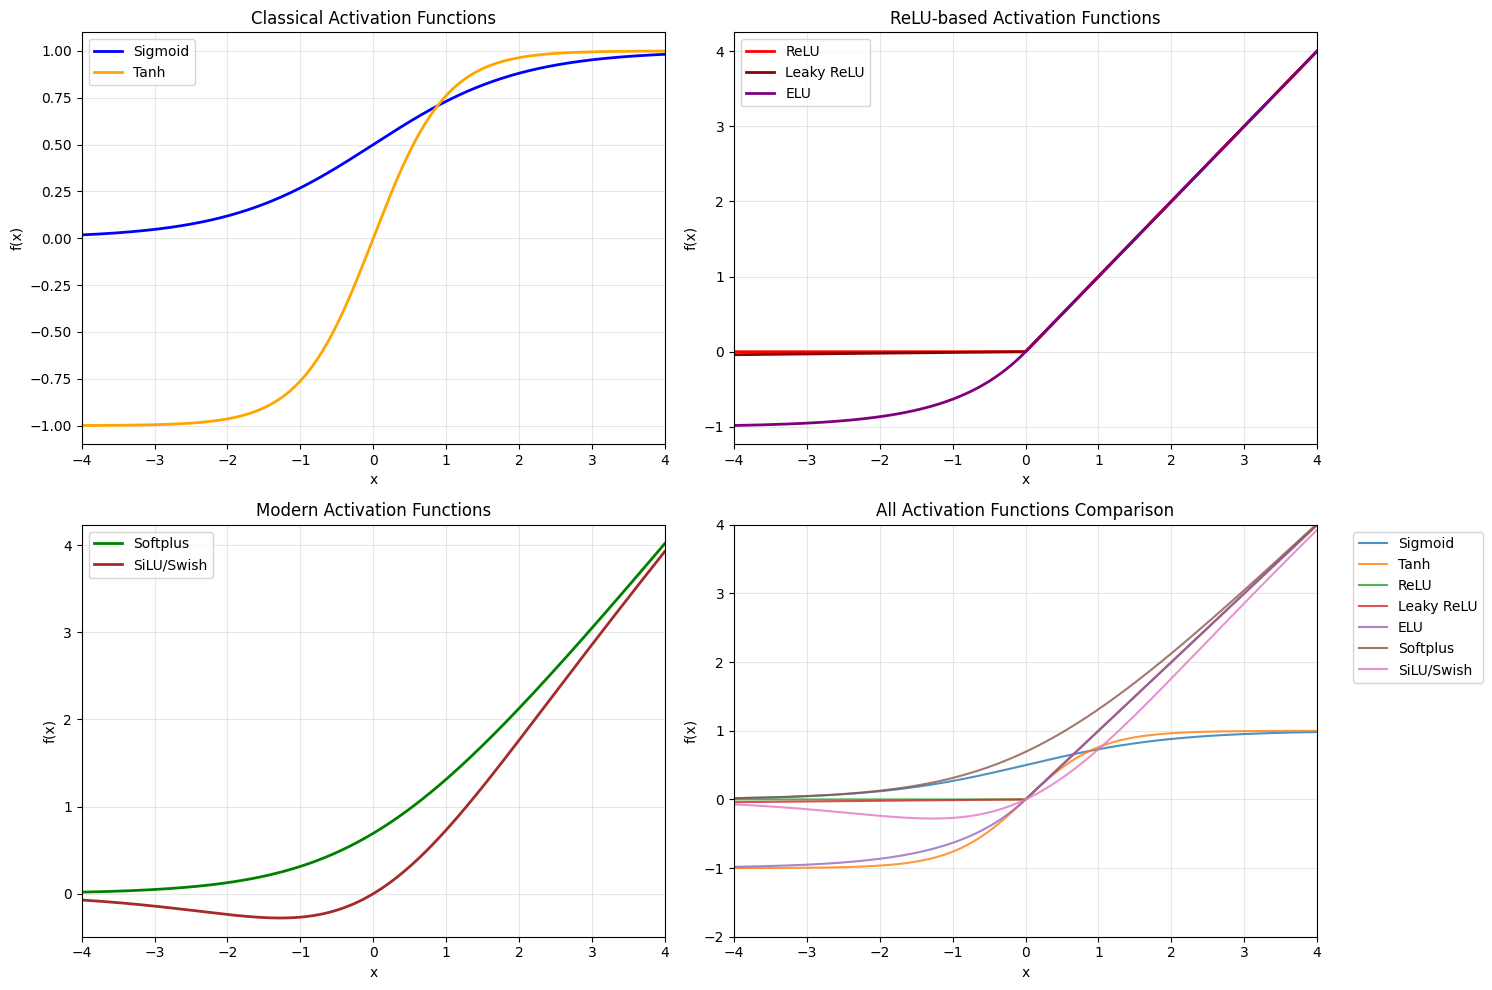

TikZ code for LaTeX:

% TikZ code for activation functions visualization
\begin{tikzpicture}[scale=0.8]
\begin{axis}[
    xlabel={$x$},
    ylabel={$f(x)$},
    title={Activation Functions Comparison},
    grid=major,
    grid style={dashed,gray!30},
    legend pos=outer north east,
    domain=-4:4,
    samples=100,
    smooth,
    axis lines=middle,
    xmin=-4.5, xmax=4.5,
    ymin=-2, ymax=4
]

% Sigmoid
\addplot[blue, thick] {1/(1+exp(-x))};
\addlegendentry{Sigmoid}

% Tanh
\addplot[orange, thick] {tanh(x)};
\addlegendentry{Tanh}

% ReLU
\addplot[red, thick] {max(0,x)};
\addlegendentry{ReLU}

% SiLU/Swish (approximation)
\addplot[brown, thick] {x/(1+exp(-x))};
\addlegendentry{SiLU/Swish}

\end{axis}
\end{tikzpicture}



In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

# Define activation functions
def sigmoid(z):
    return torch.sigmoid(z)

def tanh_func(z):
    return torch.tanh(z)

def relu(z):
    return torch.relu(z)

def leaky_relu(z, alpha=0.01):
    return F.leaky_relu(z, negative_slope=alpha)

def elu(z, alpha=1.0):
    return F.elu(z, alpha=alpha)

def softplus(z):
    return F.softplus(z)

def silu_swish(z):
    """SiLU/Swish activation function"""
    return z * torch.sigmoid(z)

# Generate input data
z = torch.linspace(-4, 4, 1000)

# Compute activations
sig = sigmoid(z)
tanh_act = tanh_func(z)
relu_act = relu(z)
leakyrelu_act = leaky_relu(z)
elu_act = elu(z)
softplus_act = softplus(z)
silu_act = silu_swish(z)

# Create comprehensive visualization
plt.figure(figsize=(15, 10))

# Plot all activation functions
plt.subplot(2, 2, 1)
plt.plot(z.numpy(), sig.numpy(), label='Sigmoid', linewidth=2, color='blue')
plt.plot(z.numpy(), tanh_act.numpy(), label='Tanh', linewidth=2, color='orange')
plt.title('Classical Activation Functions')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(-4, 4)

plt.subplot(2, 2, 2)
plt.plot(z.numpy(), relu_act.numpy(), label='ReLU', linewidth=2, color='red')
plt.plot(z.numpy(), leakyrelu_act.numpy(), label='Leaky ReLU', linewidth=2, color='darkred')
plt.plot(z.numpy(), elu_act.numpy(), label='ELU', linewidth=2, color='purple')
plt.title('ReLU-based Activation Functions')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(-4, 4)

plt.subplot(2, 2, 3)
plt.plot(z.numpy(), softplus_act.numpy(), label='Softplus', linewidth=2, color='green')
plt.plot(z.numpy(), silu_act.numpy(), label='SiLU/Swish', linewidth=2, color='brown')
plt.title('Modern Activation Functions')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(-4, 4)

plt.subplot(2, 2, 4)
# Comparison plot with all functions
plt.plot(z.numpy(), sig.numpy(), label='Sigmoid', linewidth=1.5, alpha=0.8)
plt.plot(z.numpy(), tanh_act.numpy(), label='Tanh', linewidth=1.5, alpha=0.8)
plt.plot(z.numpy(), relu_act.numpy(), label='ReLU', linewidth=1.5, alpha=0.8)
plt.plot(z.numpy(), leakyrelu_act.numpy(), label='Leaky ReLU', linewidth=1.5, alpha=0.8)
plt.plot(z.numpy(), elu_act.numpy(), label='ELU', linewidth=1.5, alpha=0.8)
plt.plot(z.numpy(), softplus_act.numpy(), label='Softplus', linewidth=1.5, alpha=0.8)
plt.plot(z.numpy(), silu_act.numpy(), label='SiLU/Swish', linewidth=1.5, alpha=0.8)
plt.title('All Activation Functions Comparison')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.xlim(-4, 4)
plt.ylim(-2, 4)

plt.tight_layout()
plt.show()

# TikZ code for LaTeX compatibility
tikz_code = """
% TikZ code for activation functions visualization
\\begin{tikzpicture}[scale=0.8]
\\begin{axis}[
    xlabel={$x$},
    ylabel={$f(x)$},
    title={Activation Functions Comparison},
    grid=major,
    grid style={dashed,gray!30},
    legend pos=outer north east,
    domain=-4:4,
    samples=100,
    smooth,
    axis lines=middle,
    xmin=-4.5, xmax=4.5,
    ymin=-2, ymax=4
]

% Sigmoid
\\addplot[blue, thick] {1/(1+exp(-x))};
\\addlegendentry{Sigmoid}

% Tanh
\\addplot[orange, thick] {tanh(x)};
\\addlegendentry{Tanh}

% ReLU
\\addplot[red, thick] {max(0,x)};
\\addlegendentry{ReLU}

% SiLU/Swish (approximation)
\\addplot[brown, thick] {x/(1+exp(-x))};
\\addlegendentry{SiLU/Swish}

\\end{axis}
\\end{tikzpicture}
"""

print("TikZ code for LaTeX:")
print(tikz_code)

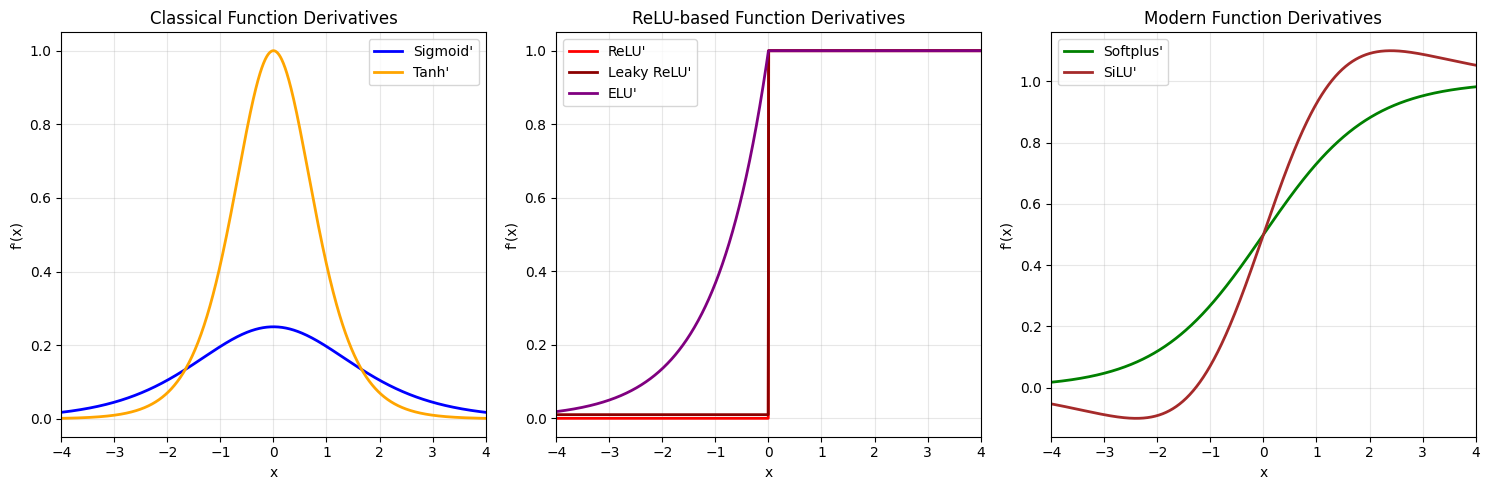

Key observations about derivatives:
• Sigmoid and Tanh derivatives: Maximum at x=0, vanish for large |x| (vanishing gradient problem)
• ReLU derivative: Constant (1) for x>0, zero for x≤0 (dead neuron problem)
• Leaky ReLU: Small positive gradient for negative inputs (addresses dead neurons)
• ELU: Smooth transition, bounded negative values
• SiLU/Swish: Non-monotonic derivative, can help with gradient flow


In [2]:
# Compute derivatives of activation functions
def sigmoid_derivative(z):
    s = sigmoid(z)
    return s * (1 - s)

def tanh_derivative(z):
    t = tanh_func(z)
    return 1 - t**2

def relu_derivative(z):
    return (z > 0).float()

def leaky_relu_derivative(z, alpha=0.01):
    return torch.where(z > 0, torch.ones_like(z), torch.full_like(z, alpha))

def elu_derivative(z, alpha=1.0):
    return torch.where(z > 0, torch.ones_like(z), elu(z, alpha) + alpha)

def softplus_derivative(z):
    return sigmoid(z)  # Derivative of softplus is sigmoid

def silu_derivative(z):
    s = sigmoid(z)
    return s + z * s * (1 - s)

# Compute derivatives
sig_deriv = sigmoid_derivative(z)
tanh_deriv = tanh_derivative(z)
relu_deriv = relu_derivative(z)
leakyrelu_deriv = leaky_relu_derivative(z)
elu_deriv = elu_derivative(z)
softplus_deriv = softplus_derivative(z)
silu_deriv = silu_derivative(z)

# Create derivative visualization
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot(z.numpy(), sig_deriv.numpy(), label="Sigmoid'", linewidth=2, color='blue')
plt.plot(z.numpy(), tanh_deriv.numpy(), label="Tanh'", linewidth=2, color='orange')
plt.title('Classical Function Derivatives')
plt.xlabel('x')
plt.ylabel("f'(x)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(-4, 4)

plt.subplot(1, 3, 2)
plt.plot(z.numpy(), relu_deriv.numpy(), label="ReLU'", linewidth=2, color='red')
plt.plot(z.numpy(), leakyrelu_deriv.numpy(), label="Leaky ReLU'", linewidth=2, color='darkred')
plt.plot(z.numpy(), elu_deriv.numpy(), label="ELU'", linewidth=2, color='purple')
plt.title('ReLU-based Function Derivatives')
plt.xlabel('x')
plt.ylabel("f'(x)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(-4, 4)

plt.subplot(1, 3, 3)
plt.plot(z.numpy(), softplus_deriv.numpy(), label="Softplus'", linewidth=2, color='green')
plt.plot(z.numpy(), silu_deriv.numpy(), label="SiLU'", linewidth=2, color='brown')
plt.title('Modern Function Derivatives')
plt.xlabel('x')
plt.ylabel("f'(x)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(-4, 4)

plt.tight_layout()
plt.show()

print("Key observations about derivatives:")
print("• Sigmoid and Tanh derivatives: Maximum at x=0, vanish for large |x| (vanishing gradient problem)")
print("• ReLU derivative: Constant (1) for x>0, zero for x≤0 (dead neuron problem)")
print("• Leaky ReLU: Small positive gradient for negative inputs (addresses dead neurons)")
print("• ELU: Smooth transition, bounded negative values")
print("• SiLU/Swish: Non-monotonic derivative, can help with gradient flow")

### TikZ Code for LaTeX Documents

For including these visualizations in LaTeX documents, you can use the following TikZ code:

```latex
% Activation Functions Plot
\begin{figure}[htbp]
\centering
\begin{tikzpicture}[scale=0.8]
\begin{axis}[
    xlabel={$x$},
    ylabel={$f(x)$},
    title={Activation Functions Comparison},
    grid=major,
    grid style={dashed,gray!30},
    legend pos=outer north east,
    domain=-4:4,
    samples=200,
    smooth,
    axis lines=middle,
    xmin=-4.5, xmax=4.5,
    ymin=-2, ymax=4,
    width=12cm,
    height=8cm
]

% Sigmoid: 1/(1+exp(-x))
\addplot[blue, thick, smooth] {1/(1+exp(-x))};
\addlegendentry{Sigmoid}

% Tanh
\addplot[orange, thick, smooth] {tanh(x)};
\addlegendentry{Tanh}

% ReLU: max(0,x)
\addplot[red, thick, smooth] coordinates {(-4,0) (0,0) (0,0) (4,4)};
\addlegendentry{ReLU}

% Leaky ReLU: max(0.01*x, x)
\addplot[red!70, thick, smooth] coordinates {(-4,-0.04) (0,0) (4,4)};
\addlegendentry{Leaky ReLU}

% ELU: x if x>0, else exp(x)-1
\addplot[purple, thick, smooth, domain=-4:0] {exp(x)-1};
\addplot[purple, thick, smooth, domain=0:4] {x};
\addlegendentry{ELU}

% Softplus: ln(1+exp(x))
\addplot[green, thick, smooth] {ln(1+exp(x))};
\addlegendentry{Softplus}

% SiLU/Swish: x/(1+exp(-x))
\addplot[brown, thick, smooth] {x/(1+exp(-x))};
\addlegendentry{SiLU/Swish}

\end{axis}
\end{tikzpicture}
\caption{Comparison of common activation functions used in neural networks}
\label{fig:activation_functions}
\end{figure}

% Derivatives Plot
\begin{figure}[htbp]
\centering
\begin{tikzpicture}[scale=0.8]
\begin{axis}[
    xlabel={$x$},
    ylabel={$f'(x)$},
    title={Derivatives of Activation Functions},
    grid=major,
    grid style={dashed,gray!30},
    legend pos=outer north east,
    domain=-4:4,
    samples=200,
    smooth,
    axis lines=middle,
    xmin=-4.5, xmax=4.5,
    ymin=-0.5, ymax=1.5,
    width=12cm,
    height=8cm
]

% Sigmoid derivative: sigmoid(x)*(1-sigmoid(x))
\addplot[blue, thick, smooth] {(1/(1+exp(-x)))*(1-(1/(1+exp(-x))))};
\addlegendentry{Sigmoid'}

% Tanh derivative: 1-tanh^2(x)
\addplot[orange, thick, smooth] {1-(tanh(x))^2};
\addlegendentry{Tanh'}

% ReLU derivative: step function
\addplot[red, thick, smooth] coordinates {(-4,0) (0,0) (0,1) (4,1)};
\addlegendentry{ReLU'}

% SiLU derivative: sigmoid(x) + x*sigmoid(x)*(1-sigmoid(x))
\addplot[brown, thick, smooth] {(1/(1+exp(-x))) + x*(1/(1+exp(-x)))*(1-(1/(1+exp(-x))))};
\addlegendentry{SiLU'}

\end{axis}
\end{tikzpicture}
\caption{Derivatives of activation functions showing gradient behavior}
\label{fig:activation_derivatives}
\end{figure}
```

**Required LaTeX packages:**
```latex
\usepackage{pgfplots}
\usepackage{tikz}
\pgfplotsset{compat=1.18}
```

## PyTorch Implementations and Usage Examples

### Complete Function Implementations

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# Complete activation function implementations
class ActivationFunctions:
    """Collection of activation functions with PyTorch implementations"""
    
    @staticmethod
    def sigmoid(x):
        """Sigmoid activation function"""
        return torch.sigmoid(x)
    
    @staticmethod
    def tanh(x):
        """Hyperbolic tangent activation function"""
        return torch.tanh(x)
    
    @staticmethod
    def relu(x):
        """Rectified Linear Unit activation function"""
        return F.relu(x)
    
    @staticmethod
    def leaky_relu(x, negative_slope=0.01):
        """Leaky ReLU activation function"""
        return F.leaky_relu(x, negative_slope=negative_slope)
    
    @staticmethod
    def elu(x, alpha=1.0):
        """Exponential Linear Unit activation function"""
        return F.elu(x, alpha=alpha)
    
    @staticmethod
    def softplus(x):
        """Softplus activation function"""
        return F.softplus(x)
    
    @staticmethod
    def silu(x):
        """SiLU/Swish activation function"""
        return F.silu(x)  # Built-in PyTorch SiLU
    
    @staticmethod
    def swish(x, beta=1.0):
        """Swish activation function (parametric version)"""
        return x * torch.sigmoid(beta * x)

# Demonstration with neural network layers
class SimpleNet(nn.Module):
    def __init__(self, activation='relu'):
        super(SimpleNet, self).__init__()
        self.fc1 = nn.Linear(10, 20)
        self.fc2 = nn.Linear(20, 10)
        self.fc3 = nn.Linear(10, 1)
        
        # Set activation function
        if activation == 'relu':
            self.activation = nn.ReLU()
        elif activation == 'silu':
            self.activation = nn.SiLU()
        elif activation == 'leaky_relu':
            self.activation = nn.LeakyReLU(0.01)
        elif activation == 'elu':
            self.activation = nn.ELU()
        elif activation == 'sigmoid':
            self.activation = nn.Sigmoid()
        elif activation == 'tanh':
            self.activation = nn.Tanh()
        else:
            self.activation = nn.ReLU()  # default
    
    def forward(self, x):
        x = self.activation(self.fc1(x))
        x = self.activation(self.fc2(x))
        x = self.fc3(x)  # No activation on output layer
        return x

# Example usage
print("Creating neural networks with different activation functions:")

# Create networks with different activations
activations = ['relu', 'silu', 'leaky_relu', 'elu', 'sigmoid', 'tanh']
networks = {}

for act in activations:
    networks[act] = SimpleNet(activation=act)
    print(f"✓ Network with {act.upper()} activation created")

# Test with sample input
sample_input = torch.randn(5, 10)  # Batch size 5, input features 10

print("\nTesting activation functions with sample input:")
print(f"Input shape: {sample_input.shape}")

for act, net in networks.items():
    with torch.no_grad():
        output = net(sample_input)
        print(f"{act.upper()}: Output shape {output.shape}, Mean: {output.mean():.4f}, Std: {output.std():.4f}")

# Custom activation function example
class CustomSiLU(nn.Module):
    """Custom implementation of SiLU activation"""
    def __init__(self, beta=1.0):
        super(CustomSiLU, self).__init__()
        self.beta = beta
    
    def forward(self, x):
        return x * torch.sigmoid(self.beta * x)

# Test custom activation
custom_silu = CustomSiLU(beta=1.5)
test_input = torch.linspace(-3, 3, 10)
custom_output = custom_silu(test_input)

print(f"\nCustom SiLU (β=1.5) test:")
print(f"Input:  {test_input.numpy()}")
print(f"Output: {custom_output.detach().numpy()}")

Creating neural networks with different activation functions:
✓ Network with RELU activation created
✓ Network with SILU activation created
✓ Network with LEAKY_RELU activation created
✓ Network with ELU activation created
✓ Network with SIGMOID activation created
✓ Network with TANH activation created

Testing activation functions with sample input:
Input shape: torch.Size([5, 10])
RELU: Output shape torch.Size([5, 1]), Mean: -0.2206, Std: 0.0974
SILU: Output shape torch.Size([5, 1]), Mean: 0.0782, Std: 0.0298
LEAKY_RELU: Output shape torch.Size([5, 1]), Mean: -0.2976, Std: 0.0148
ELU: Output shape torch.Size([5, 1]), Mean: -0.4784, Std: 0.0899
SIGMOID: Output shape torch.Size([5, 1]), Mean: -0.0059, Std: 0.0158
TANH: Output shape torch.Size([5, 1]), Mean: 0.0447, Std: 0.0902

Custom SiLU (β=1.5) test:
Input:  [-3.         -2.3333333  -1.6666666  -1.         -0.33333325  0.33333325
  1.          1.6666666   2.3333333   3.        ]
Output: [-0.03296083 -0.0683952  -0.12643029 -0.182425

## Comprehensive Comparison and Use Cases

### Classical Activation Functions
- **Sigmoid (σ):** 
  - *Advantages:* Smooth, differentiable, output bounded [0,1]
  - *Disadvantages:* Vanishing gradients for large |x|, not zero-centered
  - *Use cases:* Binary classification (output layer), gates in LSTM/GRU
  
- **Tanh:** 
  - *Advantages:* Zero-centered output [-1,1], stronger gradients than sigmoid
  - *Disadvantages:* Still suffers from vanishing gradients
  - *Use cases:* Hidden layers in shallow networks, RNN/LSTM cells

### ReLU Family
- **ReLU:** 
  - *Advantages:* Computationally efficient, mitigates vanishing gradients, sparse activation
  - *Disadvantages:* Dead neuron problem (neurons can become permanently inactive)
  - *Use cases:* Most common choice for hidden layers in deep networks
  
- **Leaky ReLU:** 
  - *Advantages:* Addresses dead ReLU problem with small negative slope
  - *Disadvantages:* Additional hyperparameter (slope) to tune
  - *Use cases:* Alternative to ReLU when dead neurons are problematic
  
- **ELU (Exponential Linear Unit):** 
  - *Advantages:* Smooth, zero-centered, bounded negative values
  - *Disadvantages:* More computationally expensive than ReLU
  - *Use cases:* Networks requiring smooth activations and better gradient flow

### Modern Activation Functions
- **Softplus:** 
  - *Advantages:* Smooth approximation of ReLU, always positive output
  - *Disadvantages:* Can saturate for large positive values
  - *Use cases:* When smooth, non-negative outputs are required
  
- **SiLU/Swish:** 
  - *Advantages:* Self-gated, smooth, non-monotonic, often outperforms ReLU
  - *Disadvantages:* More computationally expensive than ReLU
  - *Use cases:* Deep networks, transformer architectures, state-of-the-art models

### Performance Characteristics

| Function | Computational Cost | Gradient Flow | Zero-Centered | Bounded Output |
|----------|-------------------|---------------|---------------|----------------|
| Sigmoid  | Medium            | Poor (vanishing) | No           | Yes [0,1]      |
| Tanh     | Medium            | Poor (vanishing) | Yes          | Yes [-1,1]     |
| ReLU     | Low               | Good          | No           | No [0,∞)       |
| Leaky ReLU | Low             | Good          | No           | No             |
| ELU      | High              | Good          | ~Yes         | Yes (negative) |
| Softplus | Medium            | Good          | No           | No [0,∞)       |
| SiLU     | Medium            | Excellent     | ~Yes         | No             |

### Modern Usage Recommendations
- **Default choice:** Start with ReLU for most hidden layers
- **Deep networks:** Consider SiLU/Swish for better performance
- **Transformers:** SiLU is commonly used in modern transformer architectures
- **Output layers:** Choose based on task (sigmoid for binary, softmax for multi-class)
- **Special cases:** Use ELU for networks requiring smooth activations

## Summary and Key Takeaways

### Activation Functions: The Key to Non-linearity

Activation functions are essential components that enable neural networks to learn complex, non-linear relationships. Without them, even deep networks would be equivalent to linear models.

### Main Categories and Their Uses

1. **Classical Functions (Sigmoid, Tanh)**
   - Historical importance in early neural networks
   - Still used in specific contexts (gates, output layers)
   - Suffer from vanishing gradient problems

2. **ReLU Family (ReLU, Leaky ReLU, ELU)**
   - Modern workhorses of deep learning
   - Computational efficiency and gradient flow
   - Address various limitations through variants

3. **Modern Functions (Softplus, SiLU/Swish)**
   - State-of-the-art performance in many applications
   - Smooth, self-gated properties
   - Used in transformer architectures and large language models

### Practical Guidelines

- **Default choice**: Start with ReLU for hidden layers
- **Deep networks**: Consider SiLU/Swish for better gradient flow
- **Output layers**: Match to your task (sigmoid for binary, softmax for multi-class)
- **Special requirements**: Choose based on specific needs (smoothness, boundedness, etc.)

### Next Steps

- **Implementation**: See the [Artificial Neuron notebook](./artificial%20neuron.ipynb) for how these functions integrate into complete neurons
- **Architecture**: Explore how multiple neurons with activation functions form deep networks
- **Optimization**: Study how activation choice affects training dynamics and convergence

### Questions for Further Study

1. How do different activation functions affect the expressiveness of neural networks?
2. What role do activation functions play in gradient-based optimization?
3. How might new activation functions be designed for specific problem domains?

**Happy Learning!** 🧠✨